In [111]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

In [112]:

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [113]:

type(x_train)

numpy.ndarray

In [114]:

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [115]:

print(x_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [116]:
print(x_train[10].shape)

(28, 28)


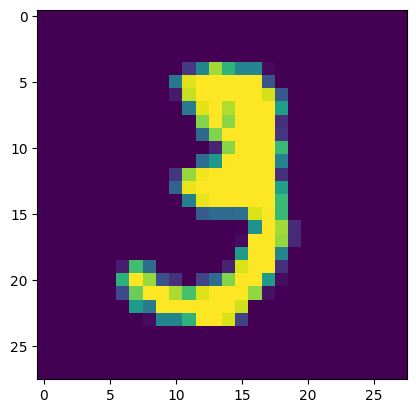

3


In [118]:

#displaying the images
plt.imshow(x_train[10])
plt.show()
#in y label
print(y_train[10])

In [119]:


cv2_imshow(x_train[10])

In [120]:


print(y_train.shape,y_test.shape)

(60000,) (10000,)


In [121]:

print(np.unique(y_train))
print(np.unique(y_test))


[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


Use these labels as such or we can apply ohe

All the images have same dimension in this dataset, if not, we have to resize all the images to a common dimension

In [122]:
x_train = x_train/255
x_test = x_test/255

In [126]:

print(x_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

Building the neural network

simple cnn method

In [128]:


# setting up layers
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

In [129]:

#compiling

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [130]:

#training the NEural network

model.fit(x_train,y_train,validation_split=0.1,epochs=10)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8464 - loss: 0.5454 - val_accuracy: 0.9623 - val_loss: 0.1345
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9547 - loss: 0.1488 - val_accuracy: 0.9702 - val_loss: 0.1053
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9683 - loss: 0.1047 - val_accuracy: 0.9710 - val_loss: 0.0971
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9756 - loss: 0.0808 - val_accuracy: 0.9743 - val_loss: 0.0954
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9801 - loss: 0.0648 - val_accuracy: 0.9723 - val_loss: 0.1015
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9832 - loss: 0.0541 - val_accuracy: 0.9720 - val_loss: 0.1092
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9863 - loss: 0.0456 - val_accuracy: 0.9717 - val_loss: 0.1149
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9887 - loss: 0.0379 - 

Test data accuracy=97.5%

In [131]:
#accuracy test data
loss,accuracy = model.evaluate(x_test,y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9672 - loss: 0.1384
0.9700000286102295


Test data accuracy=97.5%

In [132]:

print(x_test.shape)


(10000, 28, 28)


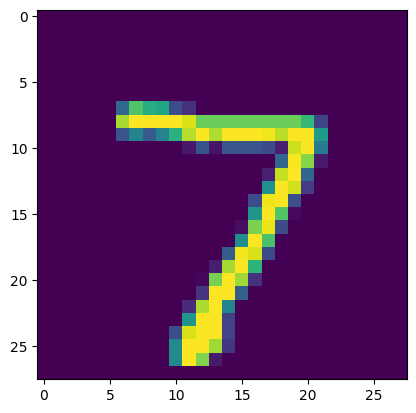

In [133]:
plt.imshow(x_test[0])
plt.show()

In [134]:


print(y_test[0])

7


In [135]:


y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [136]:
print(y_pred.shape)

(10000, 10)


In [137]:
print(y_pred[0])


[2.98572729e-07 1.28392428e-01 7.95537472e-01 9.92369831e-01
 1.09792936e-07 1.16855814e-03 8.55172934e-15 1.00000000e+00
 4.36019199e-03 8.23023438e-01]


model.predict() gives the prediction probability of each class for that data point



In [138]:
#converting the pred probability to class label for all test label
label_first=np.argmax(y_pred[0])
label_first

np.int64(7)

In [139]:


y_pred_label = [np.argmax(i) for i in y_pred]
print(y_pred_label)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(3), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

y_test --> True labels

y_pred --> predicted labels

Confusion matrix

In [141]:
conf_mat = confusion_matrix(y_test,y_pred_label)

In [88]:
conf_mat

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 955,    1,    1,    2,    1,    1,    6,    2,    5,    6],
       [   0, 1123,    1,    1,    0,    2,    2,    0,    6,    0],
       [   3,    4,  998,    4,    1,    0,    5,    8,    8,    1],
       [   0,    0,   10,  976,    0,    5,    0,    2,   17,    0],
       [   0,    3,    0,    1,  958,    1,    3,    5,    2,    9],
       [   2,    0,    0,   10,    1,  863,    7,    1,    6,    2],
       [   2,    1,    2,    0,    4,    6,  939,    1,    3,    0],
       [   0,    7,   13,    1,    0,    0,    0,  995,    5,    7],
       [   0,    0,    2,    2,    4,    7,    1,    3,  953,    2],
       [   2,    4,    0,    5,    8,    4,    0,    6,    8,  972]],
      dtype=int32)>

Text(0.5, 47.7222222222222, 'predicted label')

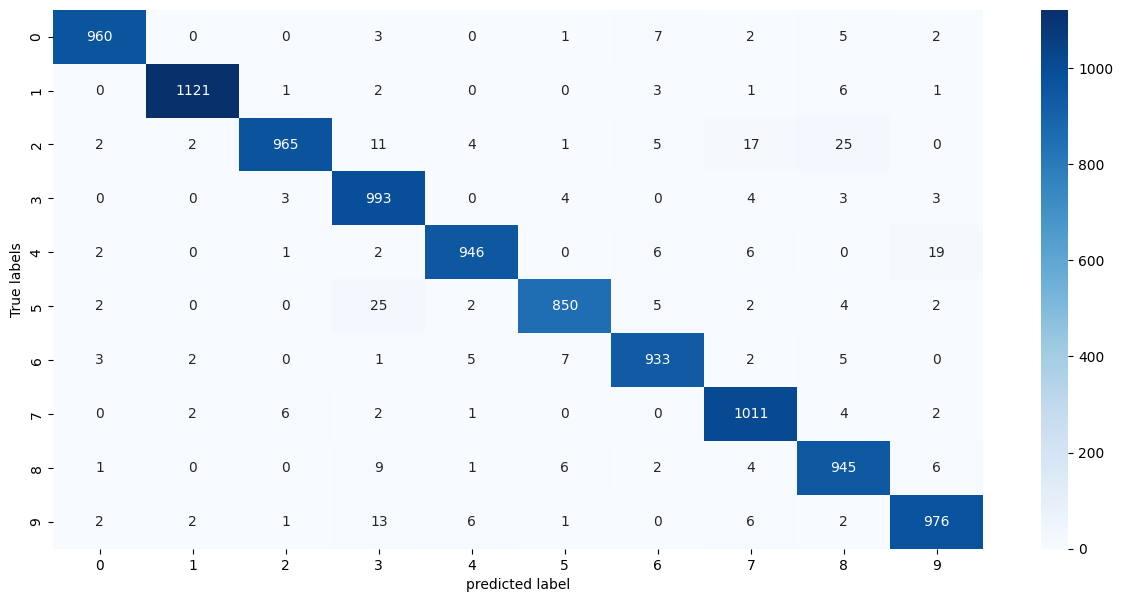

In [142]:


plt.figure(figsize=(15,7))
sns.heatmap(conf_mat, annot=True,fmt='d',cmap='Blues')
plt.ylabel('True labels')
plt.xlabel('predicted label')


Predictive system

In [143]:


input_image_path ='/content/img3.png'

input_image = cv2.imread(input_image_path)


In [144]:
type(input_image)

numpy.ndarray

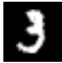

In [145]:

cv2_imshow(input_image)

In [146]:
input_image.shape

(63, 62, 3)

In [147]:

grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

In [148]:
grayscale.shape


(63, 62)

In [149]:

input_image_resize = cv2.resize(grayscale,(28,28))

In [150]:
input_image_resize.shape

(28, 28)

In [151]:
cv2_imshow(input_image_resize)

In [152]:
input_image_resize = input_image_resize/255

In [153]:
image_reshaped = np.reshape(input_image_resize,[1,28,28])

In [154]:


input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[5.2634497e-09 9.4992596e-05 2.6525189e-03 9.9985778e-01 2.2959734e-09
  4.7302754e-07 2.4400556e-15 9.9936342e-01 9.9171710e-01 9.4350451e-01]]


In [155]:

input_pred_label = np.argmax(input_prediction)
print(input_pred_label)

3


Path of the image to be predicted: /content/Screenshot 2025-11-10 140359.png


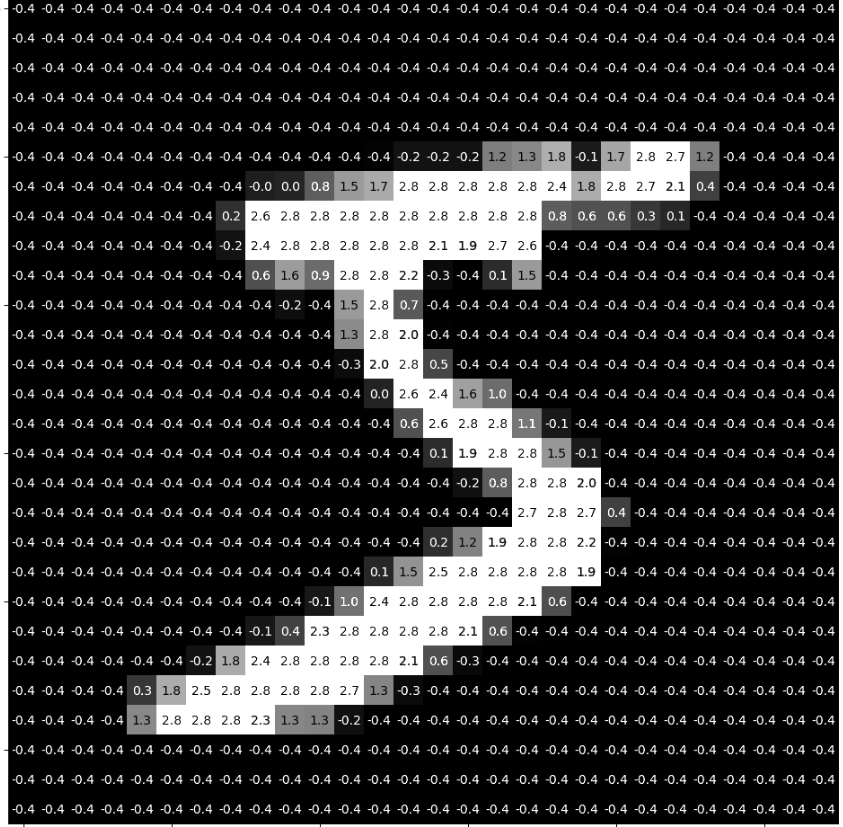

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
the handwritten digit is recognised as 5


In [156]:

input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)

input_image_resize = cv2.resize(grayscale,(28,28))

input_image_resize = input_image_resize/255

image_reshaped = np.reshape(input_image_resize,[1,28,28])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

print('the handwritten digit is recognised as',input_pred_label)

In [109]:
model.save('mnist_model.h5')

In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import cv2
from PIL import Image
import tensorflow as tf

# Load the trained model
# Make sure the model is saved in the same directory or provide the full path
# You might need to save your trained model from the Colab notebook first
# model.save('mnist_model.h5')
try:
    model = tf.keras.models.load_model('mnist_model.h5')
except:
    st.error("Model not found. Please save your trained model as 'mnist_model.h5' and place it in the same directory as the app.py file.")
    st.stop()


st.title("Handwritten Digit Recognition")
st.write("Upload an image of a handwritten digit (0-9) and the model will predict it.")

uploaded_file = st.file_uploader("Choose an image...", type=["png", "jpg", "jpeg"])

if uploaded_file is not None:
    # Read the image
    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    input_image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    st.image(input_image, caption='Uploaded Image.', use_column_width=True)

    # Preprocess the image
    grayscale = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY)
    input_image_resize = cv2.resize(grayscale, (28, 28))
    input_image_resize = input_image_resize / 255.0  # Normalize the image
    image_reshaped = np.reshape(input_image_resize, [1, 28, 28])

    # Make prediction
    input_prediction = model.predict(image_reshaped)
    input_pred_label = np.argmax(input_prediction)

    st.write(f"The handwritten digit is recognized as: **{input_pred_label}**")

In [ ]:
%%writefile requirements.txt
streamlit
numpy
opencv-python-headless
tensorflow